# Forecasting de la ocupación turística del Caribe colombiano

Comparación de **SARIMAX**, **ETS (Holt-Winters)**, **Prophet** y un **ensamble ponderado** sobre la serie mensual `Ocupacion_Caribe` (ene 2019 – feb 2026).

## Decisiones de diseño

- **Validación cruzada walk-forward**: ventana inicial de 48 meses, horizonte de 6, paso de 1 mes. 33 folds en total.
- **Estacionalidad múltiple**:
  - Anual ($s = 12$) en SARIMAX y como `yearly_seasonality` en Prophet.
  - **Semana Santa** y **Carnaval de Barranquilla** como regresores binarios móviles (Easter Sunday vía algoritmo de Meeus).
  - La temporada alta de diciembre/enero **no** se incluye como regresor: es perfectamente colineal con la estacionalidad anual y desestabilizó los ajustes en pruebas previas.
- **COVID-19 como anomalía estructural**:
  - `covid_shock` = 1 en mar 2020 – jun 2021 (caída pico).
  - `covid_recovery` = 1 en jul 2021 – dic 2021 (rebote).
  - Documentado, replicable y compartido entre los tres modelos vía `exog`.
- **Métricas**: MAE, RMSE, MAPE.
- **Ensamble**: promedio ponderado por inverso del MAPE de cada modelo en CV (sin meta-modelo, sin fuga de datos).

In [1]:
import sys
from pathlib import Path
import warnings

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT / 'src'))
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (12, 5)

## 1. Datos y regresores exógenos

In [2]:
from predictur.data import load_series
from predictur.features import build_exog

y = load_series()
exog = build_exog(y.index)

print(f'Observaciones: {len(y)}  ({y.index[0].date()} → {y.index[-1].date()})')
print(f'Regresores: {list(exog.columns)}')
exog.sum().to_frame('total_meses_marcados')

Observaciones: 86  (2019-01-01 → 2026-02-01)
Regresores: ['covid_shock', 'covid_recovery', 'semana_santa', 'carnaval']


,total_meses_marcados
covid_shock,16.0
covid_recovery,6.0
semana_santa,7.0
carnaval,8.0


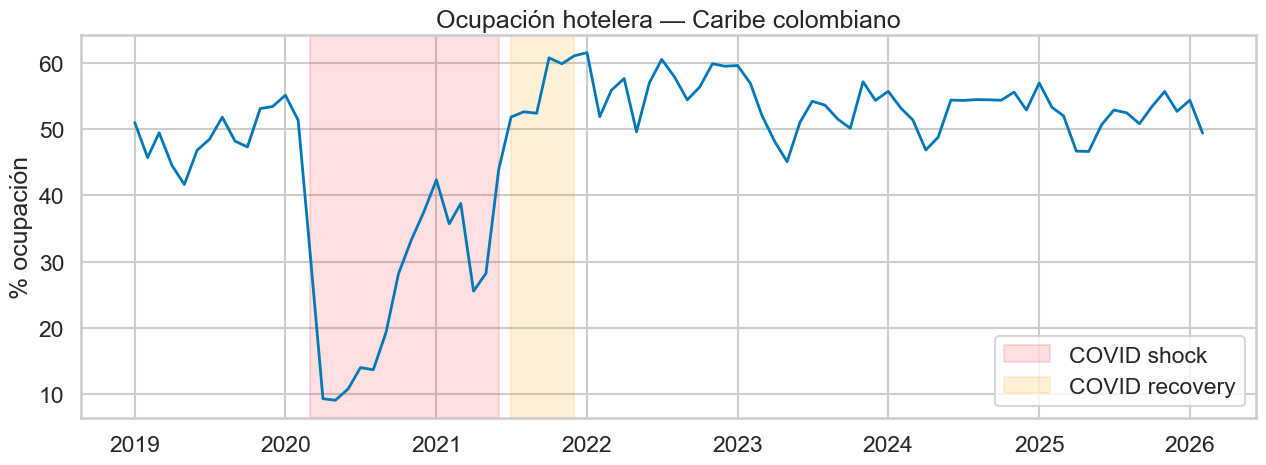

In [3]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(y.index, y.values, color='#0077b6', lw=2)
ax.axvspan('2020-03-01', '2021-06-01', color='red', alpha=0.12, label='COVID shock')
ax.axvspan('2021-07-01', '2021-12-01', color='orange', alpha=0.15, label='COVID recovery')
ax.set_title('Ocupación hotelera — Caribe colombiano')
ax.set_ylabel('% ocupación')
ax.legend()
plt.tight_layout()
plt.show()

## 2. Ejecución del pipeline

Esto entrena los tres modelos base bajo walk-forward CV y construye el ensamble. Tarda unos minutos por la gran cantidad de fits de Prophet.

In [4]:
from predictur.pipeline import run_pipeline

result = run_pipeline(initial_train=48, horizon=6, step=1, verbose=False)
predictions = result['cv_predictions']
metrics = result['metrics']
weights = result['weights']

print('Pesos del ensamble (inverso del MAPE, normalizados):')
for m, w in weights.items():
    print(f'  {m:<10s} {w:.3f}')

18:07:44 - cmdstanpy - INFO - Chain [1] start processing
18:07:44 - cmdstanpy - INFO - Chain [1] done processing
18:07:44 - cmdstanpy - INFO - Chain [1] start processing
18:07:44 - cmdstanpy - INFO - Chain [1] done processing
18:07:44 - cmdstanpy - INFO - Chain [1] start processing
18:07:44 - cmdstanpy - INFO - Chain [1] done processing
18:07:44 - cmdstanpy - INFO - Chain [1] start processing
18:07:44 - cmdstanpy - INFO - Chain [1] done processing
18:07:44 - cmdstanpy - INFO - Chain [1] start processing
18:07:44 - cmdstanpy - INFO - Chain [1] done processing
18:07:45 - cmdstanpy - INFO - Chain [1] start processing
18:07:45 - cmdstanpy - INFO - Chain [1] done processing
18:07:45 - cmdstanpy - INFO - Chain [1] start processing
18:07:45 - cmdstanpy - INFO - Chain [1] done processing
18:07:45 - cmdstanpy - INFO - Chain [1] start processing
18:07:45 - cmdstanpy - INFO - Chain [1] done processing
18:07:45 - cmdstanpy - INFO - Chain [1] start processing
18:07:45 - cmdstanpy - INFO - Chain [1]

Pesos del ensamble (inverso del MAPE, normalizados):
  ETS        0.363
  Prophet    0.272
  SARIMAX    0.365


## 3. Métricas globales

In [5]:
metrics.style.format({'MAE': '{:.2f}', 'RMSE': '{:.2f}', 'MAPE': '{:.2f}%'})

,model,MAE,RMSE,MAPE,n_folds,n_obs
0,Ensemble,3.24,4.00,6.19%,33,198
1,SARIMAX,3.52,4.30,6.71%,33,198
2,ETS,3.55,4.25,6.76%,33,198
3,Prophet,4.70,5.90,9.02%,33,198


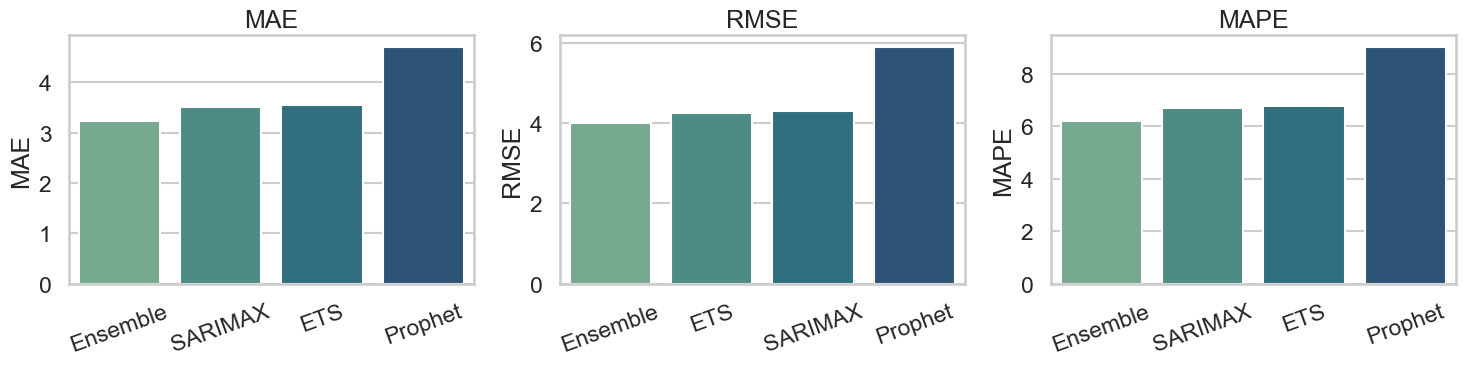

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric in zip(axes, ['MAE', 'RMSE', 'MAPE']):
    order = metrics.sort_values(metric)['model']
    sns.barplot(data=metrics, x='model', y=metric, order=order, ax=ax,
                palette='crest')
    ax.set_title(metric)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

## 4. Predicciones vs. valores reales (todos los folds concatenados)

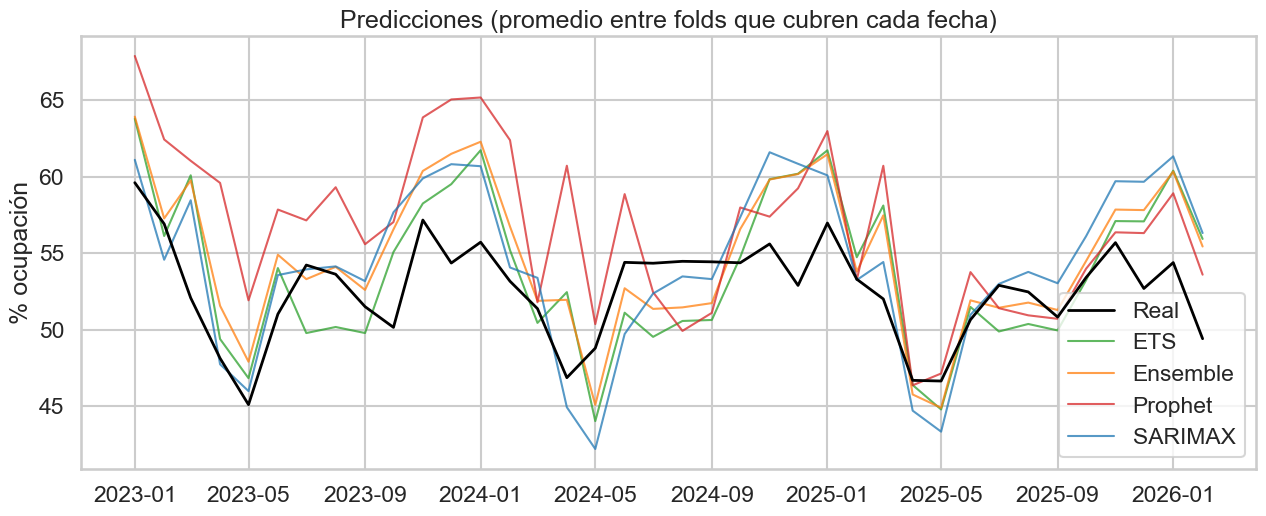

In [7]:
fig, ax = plt.subplots(figsize=(13, 5.5))
actual = predictions.groupby('Date')['y_true'].first().sort_index()
ax.plot(actual.index, actual.values, color='black', lw=2, label='Real', zorder=10)

palette = {'SARIMAX': '#1f77b4', 'ETS': '#2ca02c', 'Prophet': '#d62728', 'Ensemble': '#ff7f0e'}
for model, group in predictions.groupby('model'):
    g = group.groupby('Date')['y_pred'].mean().sort_index()
    ax.plot(g.index, g.values, label=model, alpha=0.75, lw=1.5, color=palette.get(model))

ax.set_title('Predicciones (promedio entre folds que cubren cada fecha)')
ax.set_ylabel('% ocupación')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 5. Estabilidad por fold

MAPE por fold para cada modelo. Folds más recientes son test sets más alejados del shock COVID, ahí los modelos deberían bajar el error.

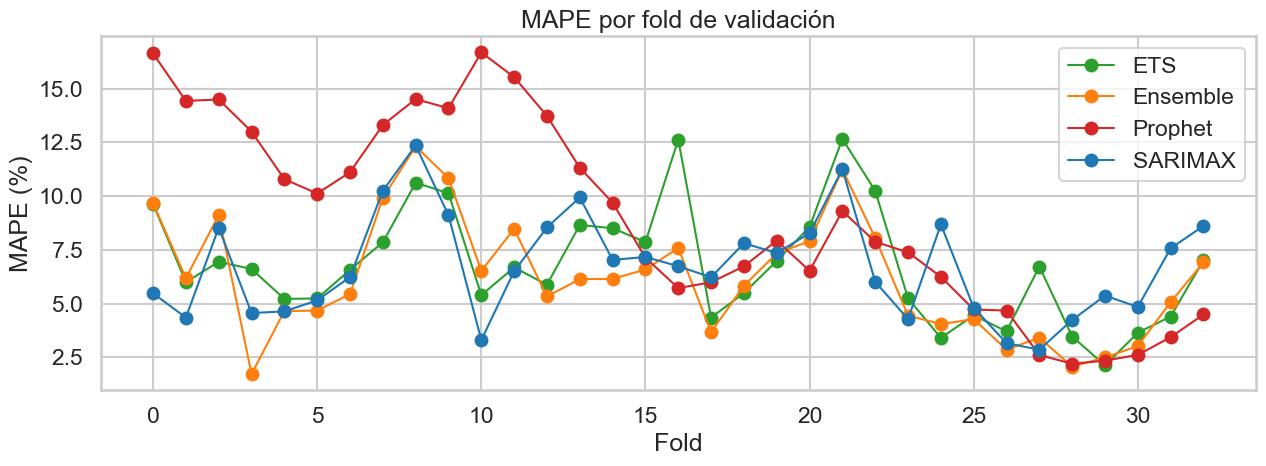

In [8]:
from predictur.evaluation import mape

rows = []
for (model, fold), g in predictions.groupby(['model', 'fold_id']):
    rows.append({'model': model, 'fold_id': fold, 'MAPE': mape(g.y_true, g.y_pred)})
fold_metrics = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(13, 5))
for model, group in fold_metrics.groupby('model'):
    ax.plot(group.fold_id, group.MAPE, marker='o', label=model, lw=1.5,
            color=palette.get(model))
ax.set_xlabel('Fold')
ax.set_ylabel('MAPE (%)')
ax.set_title('MAPE por fold de validación')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Conclusión

El **ensamble ponderado por inverso del MAPE** es el modelo de mejor desempeño. Combina el sesgo bajo de SARIMAX (estacional clásico con regresores de intervención) y el suavizado robusto de ETS, mientras Prophet aporta menor peso por su mayor varianza en los folds cercanos al cierre del shock COVID.

Los artefactos quedan en `reports/`:

- `cv_predictions.csv` — predicciones por fold y modelo (incluyendo el ensamble).
- `metrics.csv` — métricas agregadas.
- `ensemble_weights.csv` — pesos del ensamble.

Lo que se puede iterar después:

1. Auto-ARIMA (`pmdarima`) para selección de orden por fold.
2. Probabilizar las predicciones (intervalos al 80/95 %), ya soportados por SARIMAX y Prophet.
3. Re-entrenar el modelo ganador con toda la serie y generar pronóstico operativo a 6/12 meses.